# Feature Engineering 2.0
built upon 1.1.1 dataset 

In [1]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from src.features import transformers
import pandas as pd
from sklearn import set_config
set_config(transform_output="pandas")


In [2]:
#loading files
dataset_path = "../data/interim/fe_1_1_1_data.pkl"
pipeline_path = "../data/interim/models/1_1_1_data_pipeline.pkl"

df = joblib.load(dataset_path)
pipeline = joblib.load(pipeline_path)


In [3]:
df.head()

,age,sex,height_inches,weight_pounds,bmi,num_people_in_house,sw_num_days_per_week,irreg_sched,sw_9am_start_diff,sw_5pm_end_diff,...,difficulty_operating_motor_vehicles_for_long_distances_fosq,difficulty_visiting_family_or_friends_in_their_home_fosq,relationships_with_family_or_friends_affected_fosq,difficulty_watching_a_movie_fosq,difficulty_being_active_in_evening_fosq,difficulty_being_active_in_morning_fosq,effect_on_desire_for_intimacy_or_sex_fosq,fosq_summary_score,type_of_pap_device,ahi
0,30,F,67,188.0,29.4,4,<NA>,False,-1.00,0.0,...,2,1,1,2,1.0,1.0,2,8,<NA>,0.4
1,30,F,67,165.0,25.8,3,3,True,-2.00,2.0,...,4,3,3,3,3.0,3.0,3,14,<NA>,1.0
2,42,M,64,156.0,26.8,0,7,True,-3.00,3.0,...,4,3,4,3,2.0,2.0,4,16,<NA>,3.9
3,36,M,63,255.0,45.2,3,5,True,-0.75,0.5,...,4,4,3,3,2.0,2.0,2,15,False,1.3
4,41,F,66,186.0,30.0,6,<NA>,None,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,2.5


In [4]:
rfc_model = RandomForestClassifier(random_state=42)



X = df.drop("ahi", axis=1)

datetime_cols = X.select_dtypes(include=["datetime", "datetime64"]).columns

X = X.drop(columns=datetime_cols)


y = df["ahi"].where(df["ahi"] >= 5, 1).where(df["ahi"] < 5, 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

rfc_model.fit(X_train_transformed, y_train)


/Users/jack/Repos/apnea-predictor/src/features/transformers.py:145: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... True False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_transformed.loc[:, self.columns] = self.imputer.transform(
/Users/jack/Repos/apnea-predictor/src/features/transformers.py:145: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_transformed.loc[:, self.columns] = self.imputer.transform(
/Users/jack/Repos/apnea-predictor/src/features/transformers.py:145: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[True True True ... False True True]' has dtype incompatibl

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
# TODO: this doesnt get full list of features gah

feature_names = X_train_transformed.columns.tolist()
importances = rfc_model.feature_importances_
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}
 ).sort_values(by="importance", ascending=False)


In [6]:
import xgboost as xgb
import shap


model = xgb.XGBClassifier(random_state=42, n_estimators=1000, max_depth=6, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8)
model.fit(X_train_transformed, y_train)

preds = model.predict(X_test_transformed)
print(classification_report(y_test, preds))


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


              precision    recall  f1-score   support

         0.0       0.73      0.97      0.83       256
         1.0       0.53      0.08      0.14       101

    accuracy                           0.72       357
   macro avg       0.63      0.53      0.49       357
weighted avg       0.67      0.72      0.64       357



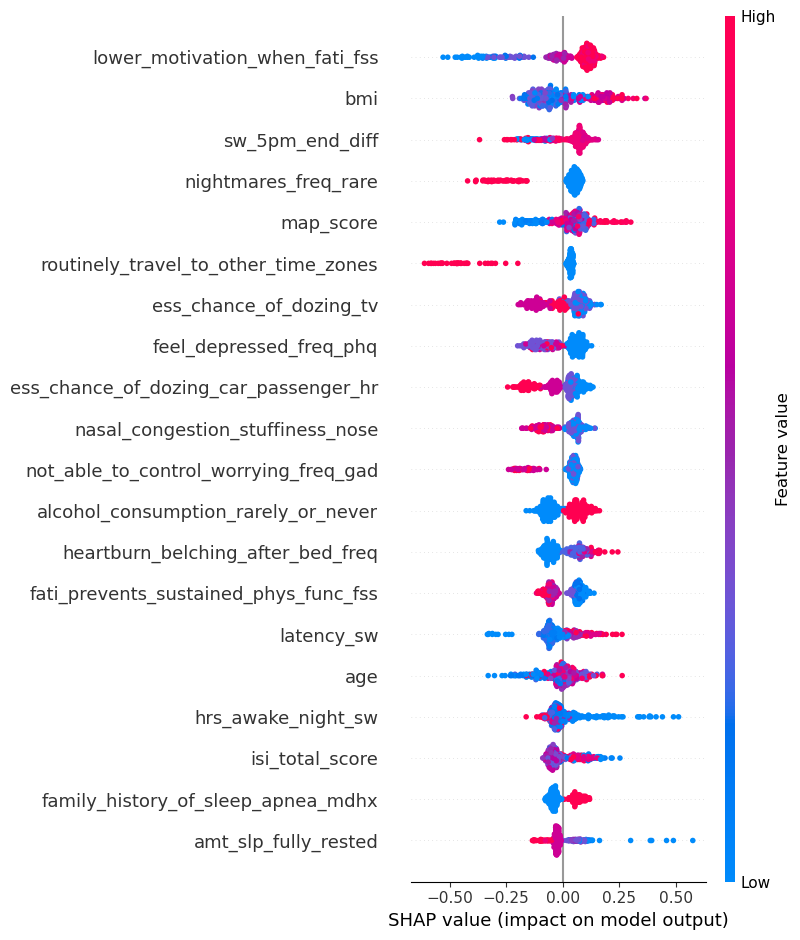

In [7]:
explainer = shap.TreeExplainer(model, X_train_transformed)
shap_values = explainer.shap_values(X_test_transformed)

explanations = explainer(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed)


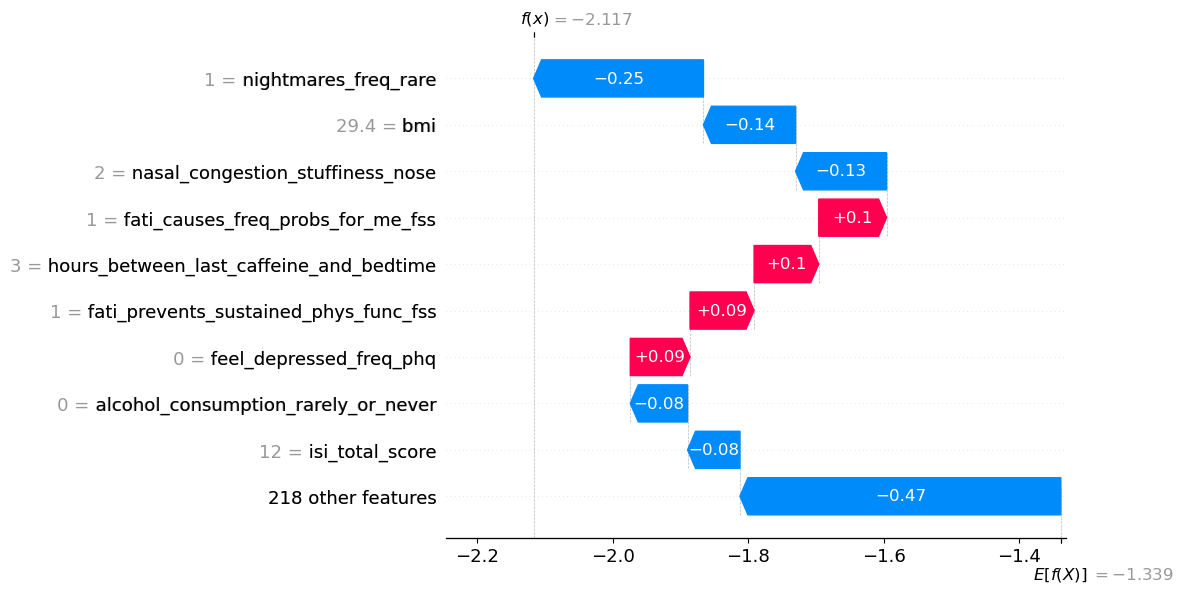

In [10]:
# random ass prediction

shap.plots.waterfall(explanations[1])

In [12]:
from sklearn.feature_selection import RFECV

selector = RFECV(estimator=model, step=1, cv=5, scoring='accuracy')

selector = selector.fit(X_train_transformed, y_train)


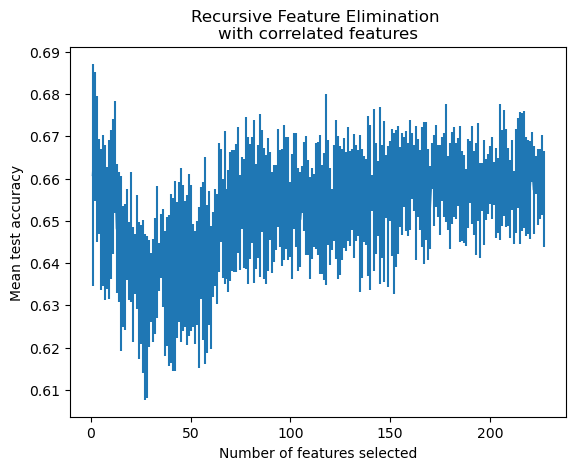

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    key: value
    for key, value in selector.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(data)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import VarianceThreshold

